In [1]:
import pypsa

In [ ]:
n = pypsa.Network(name="test_case")

# n.madd("Bus", ["generation_bus", "load_bus"])
n.add("Bus", name="generation_bus", carrier="electricity")
n.add("Bus", name="load_bus", carrier="electricity")

n.add("Generator", name="coal plant", bus="generation_bus", p_nom=300, marginal_cost=3)
n.add("Generator", name="gas plant", bus="generation_bus", p_nom=400, marginal_cost=4)
n.add("Load", name="load", bus="load_bus", p_set=500)

# alternative ways of defining the link
# option A: capital expansion with no cost
n.add("Link", name="transmission", bus0="generation_bus", bus1="load_bus", p_nom_max=1000, p_nom_extendable=True, efficiency=1.0, carrier="electricity")
# option B: fixed capacity
# n.add("Link", name="transmission", bus0="generation_bus", bus1="load_bus", p_nom=1000, efficiency=1.0, carrier="electricity")

/opt/anaconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning:

facecolor will have no effect as it has been defined as "never".

/opt/anaconda3/envs/pypsa-earth/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:842: UserWarning:

Attempting to set identical low and high ylims makes transformation singular; automatically expanding.



(<matplotlib.collections.PatchCollection at 0x141f4d010>,
 <matplotlib.collections.LineCollection at 0x141fd6850>)

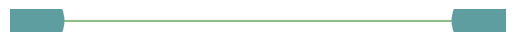

In [16]:
n.plot()

In [24]:
n.optimize()

Index(['transmission'], dtype='object', name='Link')
Index(['generation_bus', 'load_bus'], dtype='object', name='Bus')
Index(['transmission'], dtype='object', name='Link')
Index(['generation_bus', 'load_bus'], dtype='object', name='Bus')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.01s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 4 primals, 10 duals
Objective: 1.70e+03
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Link-ext-p-lower, Link-ext-p-upper were not assigned to the network.


Running HiGHS 1.11.0 (git hash: n/a): Copyright (c) 2025 HiGHS under MIT licence terms
LP   linopy-problem-od07s535 has 10 rows; 4 cols; 13 nonzeros
Coefficient ranges:
  Matrix [1e+00, 1e+00]
  Cost   [3e+00, 4e+00]
  Bound  [0e+00, 0e+00]
  RHS    [3e+02, 1e+03]
Presolving model
1 rows, 2 cols, 2 nonzeros  0s
0 rows, 0 cols, 0 nonzeros  0s
Presolve : Reductions: rows 0(-10); columns 0(-4); elements 0(-13) - Reduced to empty
Solving the original LP from the solution after postsolve
Model name          : linopy-problem-od07s535
Model status        : Optimal
Objective value     :  1.7000000000e+03
P-D objective error :  0.0000000000e+00
HiGHS run time      :          0.00
Writing the solution to /private/var/folders/nf/f5t0jzpx1wd65j9_bm73yb9r0000gn/T/linopy-solve-3xmgd97n.sol


('ok', 'optimal')

In [25]:
n.model.to_file("test.lp")

INFO:linopy.io: Writing time: 0.02s


PosixPath('test.lp')